In [1]:
import pandas as pd
import numpy as np

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = pd.read_csv("merged.csv")

In [3]:
data.head()

,credit_score,oldest_credit_line_age,oldest_account_age_months,num_credit_accounts,num_inquiries_6mo,account_diversity_index,total_delinquencies,credit_utilization_ratio,recent_inquiry_ratio,id,...,num_login_sessions,num_customer_service_calls,account_status_code,paperless_billing,has_mobile_app,account_open_year,preferred_contact,application_hour,application_day_of_week,default
0,696,22.0,264.0,14,2,0.499,1.0,12078.571429,0.142857,10000,...,13,2,2,1,1,2013,1,5,6,0
1,659,3.5,42.0,13,5,0.298,0.0,6015.384615,0.384615,10001,...,6,1,3,1,1,2015,2,4,2,1
2,662,0.0,0.0,3,2,0.174,0.0,13800.000000,0.666667,10002,...,2,2,3,0,1,2020,2,10,3,0
3,676,9.0,108.0,8,1,0.263,0.0,7500.000000,0.125000,10003,...,4,1,0,1,1,2010,0,7,5,0
4,678,8.0,96.0,7,1,0.298,0.0,7100.000000,0.142857,10004,...,6,2,3,0,1,2020,1,1,2,0


In [19]:
import pandas as pd

# Datasetni yuklash
df = pd.read_csv("merged.csv")

# Dataset haqida umumiy ma'lumot
print("Dataset info:")
print(df.info())

# Birinchi 5 qatorni ko'rish
print("\nDataset sample:")
print(df.head())

# Target ustunini aniqlash
target_col = 'target' if 'target' in df.columns else df.columns[-1]
X = df.drop(target_col, axis=1)
y = df[target_col]


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89999 entries, 0 to 89998
Data columns (total 60 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   credit_score                89999 non-null  int64  
 1   oldest_credit_line_age      89999 non-null  float64
 2   oldest_account_age_months   89999 non-null  float64
 3   num_credit_accounts         89999 non-null  int64  
 4   num_inquiries_6mo           89999 non-null  int64  
 5   account_diversity_index     89999 non-null  float64
 6   total_delinquencies         89167 non-null  float64
 7   credit_utilization_ratio    89999 non-null  float64
 8   recent_inquiry_ratio        89999 non-null  float64
 9   id                          89999 non-null  int64  
 10  age                         89999 non-null  int64  
 11  annual_income               89999 non-null  float64
 12  employment_length           89999 non-null  float64
 13  employment_type  

In [20]:
# Categorical ustunlar
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
# Numerical ustunlar
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


Categorical columns: Index(['state'], dtype='object')
Numerical columns: Index(['credit_score', 'oldest_credit_line_age', 'oldest_account_age_months',
       'num_credit_accounts', 'num_inquiries_6mo', 'account_diversity_index',
       'total_delinquencies', 'credit_utilization_ratio',
       'recent_inquiry_ratio', 'id', 'age', 'annual_income',
       'employment_length', 'employment_type', 'education', 'marital_status',
       'num_dependents', 'employment_type_num', 'education_num',
       'marital_status_num', 'monthly_income', 'existing_monthly_debt',
       'monthly_payment', 'debt_to_income_ratio', 'debt_service_ratio',
       'payment_to_income_ratio', 'credit_utilization', 'credit_usage_amount',
       'available_credit', 'total_monthly_debt_payment', 'annual_debt_payment',
       'loan_to_annual_income', 'total_debt_amount', 'monthly_free_cash_flow',
       'regional_unemployment_rate', 'regional_median_income',
       'regional_median_rent', 'housing_price_index', 'cost_of_l

In [21]:
from sklearn.impute import SimpleImputer

# Numerical ustunlar uchun o'rtacha
num_imputer = SimpleImputer(strategy='mean')
# Categorical ustunlar uchun eng ko'p uchraydigan qiymat
cat_imputer = SimpleImputer(strategy='most_frequent')

X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

# Tekshirish
print("\nMissing values after imputation:\n", X.isna().sum())



Missing values after imputation:
 credit_score                  0
oldest_credit_line_age        0
oldest_account_age_months     0
num_credit_accounts           0
num_inquiries_6mo             0
account_diversity_index       0
total_delinquencies           0
credit_utilization_ratio      0
recent_inquiry_ratio          0
id                            0
age                           0
annual_income                 0
employment_length             0
employment_type               0
education                     0
marital_status                0
num_dependents                0
employment_type_num           0
education_num                 0
marital_status_num            0
monthly_income                0
existing_monthly_debt         0
monthly_payment               0
debt_to_income_ratio          0
debt_service_ratio            0
payment_to_income_ratio       0
credit_utilization            0
credit_usage_amount           0
available_credit              0
total_monthly_debt_payment    0
annua

In [24]:
from sklearn.preprocessing import OneHotEncoder

# One-Hot Encoder (yangi versiyada sparse_output)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = pd.DataFrame(
    ohe.fit_transform(X[categorical_cols]),
    columns=ohe.get_feature_names_out(categorical_cols)
)

# Numerical ustunlarni qo‘shish
X_final = pd.concat([X[numerical_cols].reset_index(drop=True), X_encoded.reset_index(drop=True)], axis=1)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)


In [27]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train_bal, y_train_bal)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
# Prediktsiya
y_pred = model.predict(X_test)

# Confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[17037    44]
 [  883    36]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97     17081
           1       0.45      0.04      0.07       919

    accuracy                           0.95     18000
   macro avg       0.70      0.52      0.52     18000
weighted avg       0.93      0.95      0.93     18000



ROC-AUC Score: 0.7789995552777749


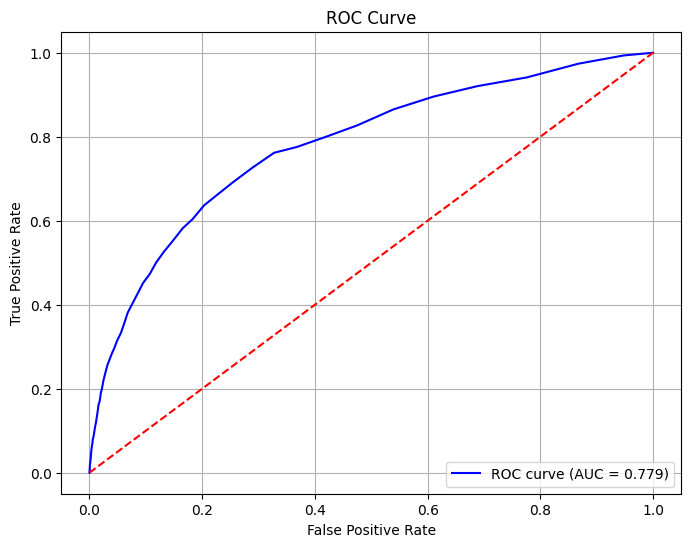

In [29]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Test set uchun probabilistic prediktsiya (RandomForest predict_proba)
y_proba = model.predict_proba(X_test)[:, 1]  # 1-klass ehtimoli

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')  # Random guess
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


[LightGBM] [Info] Number of positive: 68324, number of negative: 68324
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011983 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19380
[LightGBM] [Info] Number of data points in the train set: 136648, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.784247	valid_0's binary_logloss: 0.22918
[100]	valid_0's auc: 0.795162	valid_0's binary_logloss: 0.179031
[150]	valid_0's auc: 0.801998	valid_0's binary_logloss: 0.169753
[200]	valid_0's auc: 0.803868	valid_0's binary_logloss: 0.167731
[250]	valid_0's auc: 0.804202	valid_0's binary_logloss: 0.167239
Early stopping, best iteration is:
[212]	valid_0's auc: 0.804676	valid_0's binary_logloss: 0.167408
Improved RO

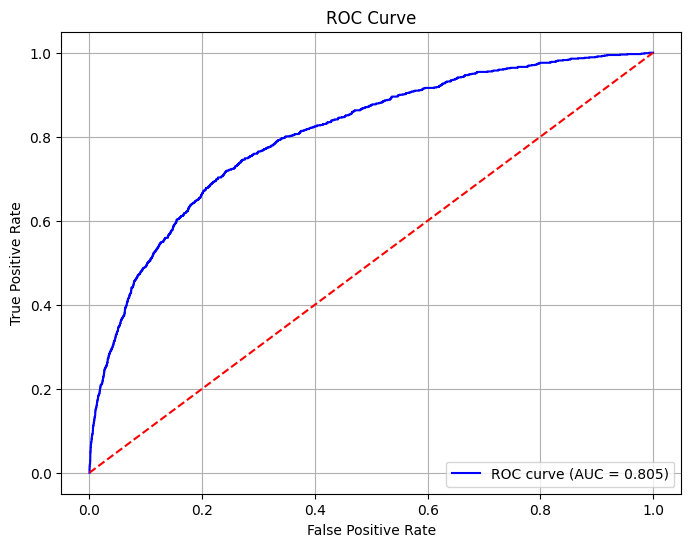

In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import lightgbm as lgb

# Dataset
df = pd.read_csv("merged.csv")

# Target va features
target_col = 'target' if 'target' in df.columns else df.columns[-1]
X = df.drop([target_col, 'id', 'previous_zip_code'], axis=1)  # noizli ustunlar
y = df[target_col]

# Categorical va numerical ustunlar
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Missing values
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

# One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = pd.DataFrame(
    ohe.fit_transform(X[categorical_cols]),
    columns=ohe.get_feature_names_out(categorical_cols)
)
X_final = pd.concat([X[numerical_cols].reset_index(drop=True), X_encoded.reset_index(drop=True)], axis=1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# LightGBM model
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    n_jobs=-1
)

# Fit with callbacks for early stopping
lgb_model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)]
)

# Prediktsiya va AUC
y_proba = lgb_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print("Improved ROC-AUC Score:", roc_auc)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import lightgbm as lgb

# Datasetni yuklash
df = pd.read_csv("merged.csv")

# Faqat kerakli ustunlar
columns_to_use = [
    'credit_score', 'oldest_credit_line_age', 'oldest_account_age_months',
    'num_credit_accounts', 'num_inquiries_6mo', 'account_diversity_index',
    'total_delinquencies', 'credit_utilization_ratio', 'recent_inquiry_ratio',
    'num_login_sessions', 'num_customer_service_calls', 'account_status_code',
    'paperless_billing', 'has_mobile_app', 'account_open_year', 'preferred_contact',
    'application_hour', 'application_day_of_week'
]

df = df[columns_to_use]

# Target va features
target_col = 'default'
X = df.drop(target_col, axis=1)
y = df[target_col]

# Categorical va numerical ustunlar
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Missing values to'ldirish
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])
if len(categorical_cols) > 0:
    X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

# One-Hot Encoding faqat kategorik ustunlar uchun
if len(categorical_cols) > 0:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_encoded = pd.DataFrame(
        ohe.fit_transform(X[categorical_cols]),
        columns=ohe.get_feature_names_out(categorical_cols)
    )
    X_final = pd.concat([X[numerical_cols].reset_index(drop=True), X_encoded.reset_index(drop=True)], axis=1)
else:
    X_final = X

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE bilan balanslash
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# LightGBM model
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    n_jobs=-1
)

# Modelni fit qilish (callbacks bilan early stopping)
lgb_model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)]
)

# Prediktsiya va ROC-AUC
y_proba = lgb_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)

# ROC curve chizish
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


KeyError: "['default'] not found in axis"

[LightGBM] [Info] Number of positive: 68324, number of negative: 68324
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014692 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19380
[LightGBM] [Info] Number of data points in the train set: 136648, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.784247	valid_0's binary_logloss: 0.22918
[100]	valid_0's auc: 0.795162	valid_0's binary_logloss: 0.179031
[150]	valid_0's auc: 0.801998	valid_0's binary_logloss: 0.169753
[200]	valid_0's auc: 0.803868	valid_0's binary_logloss: 0.167731
[250]	valid_0's auc: 0.804202	valid_0's binary_logloss: 0.167239
Early stopping, best iteration is:
[212]	valid_0's auc: 0.804676	valid_0's binary_logloss: 0.167408
ROC-AUC Sco

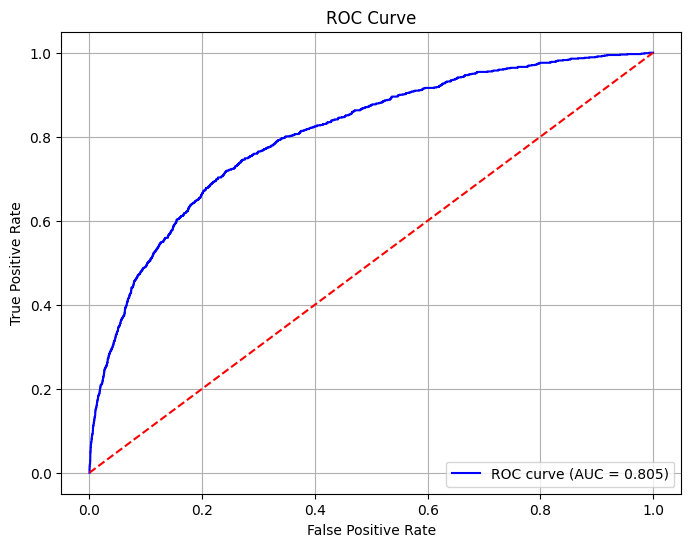

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import lightgbm as lgb

# Dataset
df = pd.read_csv("merged.csv")

# Target va features
target_col = 'default'  # default ustuni target bo'ladi
X = df.drop([target_col, 'id', 'previous_zip_code'], axis=1)  # keraksiz ustunlar
y = df[target_col]

# Categorical va numerical ustunlar
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Missing values to'ldirish
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])
if len(categorical_cols) > 0:
    X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

# One-Hot Encoding (agar kategorik ustunlar mavjud bo'lsa)
if len(categorical_cols) > 0:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_encoded = pd.DataFrame(
        ohe.fit_transform(X[categorical_cols]),
        columns=ohe.get_feature_names_out(categorical_cols)
    )
    X_final = pd.concat([X[numerical_cols].reset_index(drop=True), X_encoded.reset_index(drop=True)], axis=1)
else:
    X_final = X

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE bilan balanslash
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# LightGBM model
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    n_jobs=-1
)

# Modelni fit qilish (callbacks bilan early stopping)
lgb_model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)]
)

# Prediktsiya va ROC-AUC
y_proba = lgb_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)

# ROC curve chizish
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import lightgbm as lgb

# Datasetni yuklash
df = pd.read_csv("merged.csv")

# Features va target
target_col = 'default'
X = df.drop([target_col, 'id', 'previous_zip_code'], axis=1)  # noizli ustunlar
y = df[target_col]

# Categorical ustunlar indeksi
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
categorical_indices = [X.columns.get_loc(col) for col in categorical_cols]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTENC bilan balanslash (categorical_features ni ko‘rsatish)
smote = SMOTENC(categorical_features=categorical_indices, random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# LightGBM model
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    n_jobs=-1
)

# Modelni fit qilish
lgb_model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)]
)

# Prediktsiya va ROC-AUC
y_proba = lgb_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)

# ROC curve chizish
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


ParserError: Error tokenizing data. C error: out of memory

[LightGBM] [Info] Number of positive: 68324, number of negative: 68324
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007785 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3103
[LightGBM] [Info] Number of data points in the train set: 136648, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.738522	valid_0's binary_logloss: 0.27088
[100]	valid_0's auc: 0.743542	valid_0's binary_logloss: 0.205549
[150]	valid_0's auc: 0.750195	valid_0's binary_logloss: 0.186745
[200]	valid_0's auc: 0.754673	valid_0's binary_logloss: 0.180839
[250]	valid_0's auc: 0.75849	valid_0's binary_logloss: 0.178772
[300]	valid_0's auc: 0.759469	valid_0's binary_logloss: 0.178317
[350]	valid_0's auc: 0.760078	valid_0's binary_logloss: 0.177998
[400]	valid_0's auc: 0.759582	valid_0's binary_

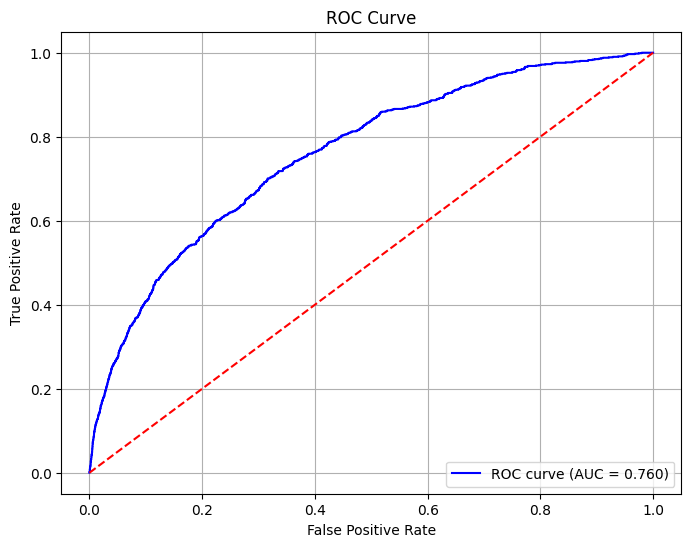

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTENC
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import lightgbm as lgb
import numpy as np

# Kerakli ustunlar
cols_to_use = [
    'credit_score', 'oldest_credit_line_age', 'oldest_account_age_months',
    'num_credit_accounts', 'num_inquiries_6mo', 'account_diversity_index',
    'total_delinquencies', 'credit_utilization_ratio', 'recent_inquiry_ratio',
    'num_login_sessions', 'num_customer_service_calls', 'account_status_code',
    'paperless_billing', 'has_mobile_app', 'account_open_year', 'preferred_contact',
    'application_hour', 'application_day_of_week', 'default'
]

# Faylni faqat kerakli ustunlar bilan o'qish
df = pd.read_csv("merged.csv", usecols=cols_to_use)

# Target va features
target_col = 'default'
X = df.drop(target_col, axis=1)
y = df[target_col]

# Categorical ustunlar (butun sonlar va kodlangan kategoriyalar)
categorical_cols = ['account_status_code', 'paperless_billing', 'has_mobile_app',
                    'preferred_contact', 'application_hour', 'application_day_of_week']
categorical_idx = [X.columns.get_loc(col) for col in categorical_cols]

# Numerical ustunlar
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Missing values to'ldirish
num_imputer = SimpleImputer(strategy='mean')
X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTENC bilan balanslash
smote = SMOTENC(categorical_features=categorical_idx, random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# LightGBM model
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    n_jobs=-1
)

# Fit qilish (callbacks bilan early stopping)
lgb_model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)]
)

# Prediktsiya va ROC-AUC
y_proba = lgb_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)

# ROC curve chizish
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
